In [6]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "outputs"
MODEL_DIR = "models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42

In [7]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded from committed titanic.csv")
print("Shape:", df.shape)

df.head()

Dataset loaded from committed titanic.csv
Shape: (889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [8]:
print("Missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values:
Series([], dtype: int64)


In [9]:
class_balance = (
    df["survived"]
    .value_counts()
    .sort_index()
)

class_balance_percentage = (
    df["survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Class counts:")
print(class_balance)

print("\nClass percentages:")
print(class_balance_percentage)

Class counts:
0    549
1    340
Name: survived, dtype: int64

Class percentages:
0    61.75
1    38.25
Name: survived, dtype: float64


In [10]:
feature_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[feature_columns].copy()
y = df["survived"].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target:
survived


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training shape: (711, 7)
Testing shape : (178, 7)

Training class distribution:
0    0.61744
1    0.38256
Name: survived, dtype: float64

Testing class distribution:
0    0.617978
1    0.382022
Name: survived, dtype: float64


### Why Stratification?

The Titanic target contains two classes: survived and not survived.
A stratified train/test split preserves approximately the same class
proportion in both subsets. This makes model evaluation more representative
of the original target distribution.

In [12]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [14]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [15]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [16]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

In [17]:
def evaluate_classifier(
    name,
    y_true,
    y_pred,
    y_probability
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        y_probability
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "Confusion Matrix": cm
    }

In [18]:
classification_results = []

for name in models:
    result = evaluate_classifier(
        name,
        y_test,
        predictions[name],
        probabilities[name]
    )

    classification_results.append(result)

classification_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8089887640449438,
  'Precision': 0.7833333333333333,
  'Recall': 0.6911764705882353,
  'F1': 0.7343749999999999,
  'AUC': 0.8609625668449198,
  'Confusion Matrix': array([[97, 13],
         [21, 47]])},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7640449438202247,
  'Precision': 0.76,
  'Recall': 0.5588235294117647,
  'F1': 0.6440677966101696,
  'AUC': 0.8373663101604277,
  'Confusion Matrix': array([[98, 12],
         [30, 38]])},
 {'Model': 'Random Forest',
  'Accuracy': 0.8089887640449438,
  'Precision': 0.765625,
  'Recall': 0.7205882352941176,
  'F1': 0.7424242424242423,
  'AUC': 0.8210561497326203,
  'Confusion Matrix': array([[95, 15],
         [19, 49]])}]

In [19]:
classification_table = pd.DataFrame(
    classification_results
)

classification_table[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
].round(4)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.809,0.7656,0.7206,0.7424,0.8211


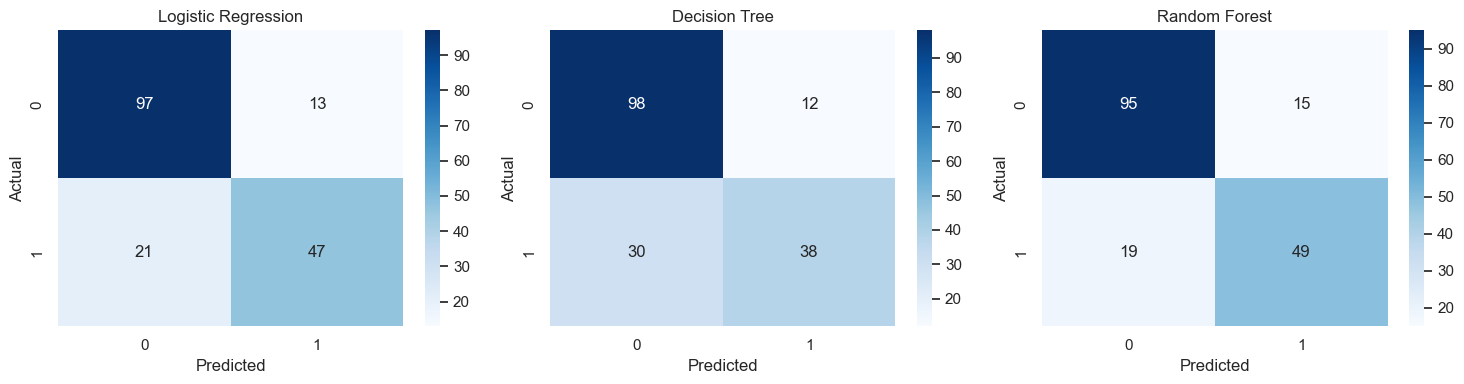

In [20]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, name in zip(
    axes,
    models.keys()
):

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "confusion_matrices.png"
    ),
    dpi=150
)

plt.show()

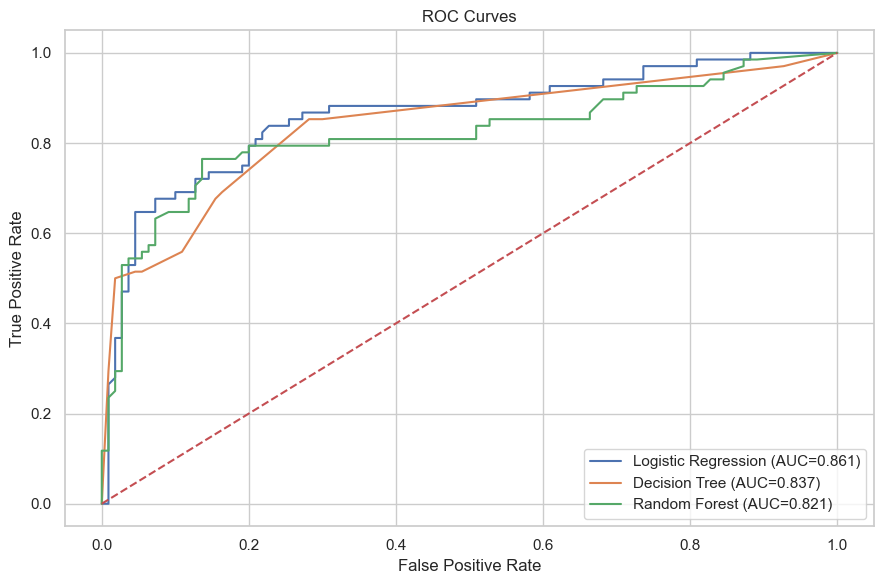

In [21]:
plt.figure(figsize=(9, 6))

for name in models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "roc_curves.png"
    ),
    dpi=150
)

plt.show()

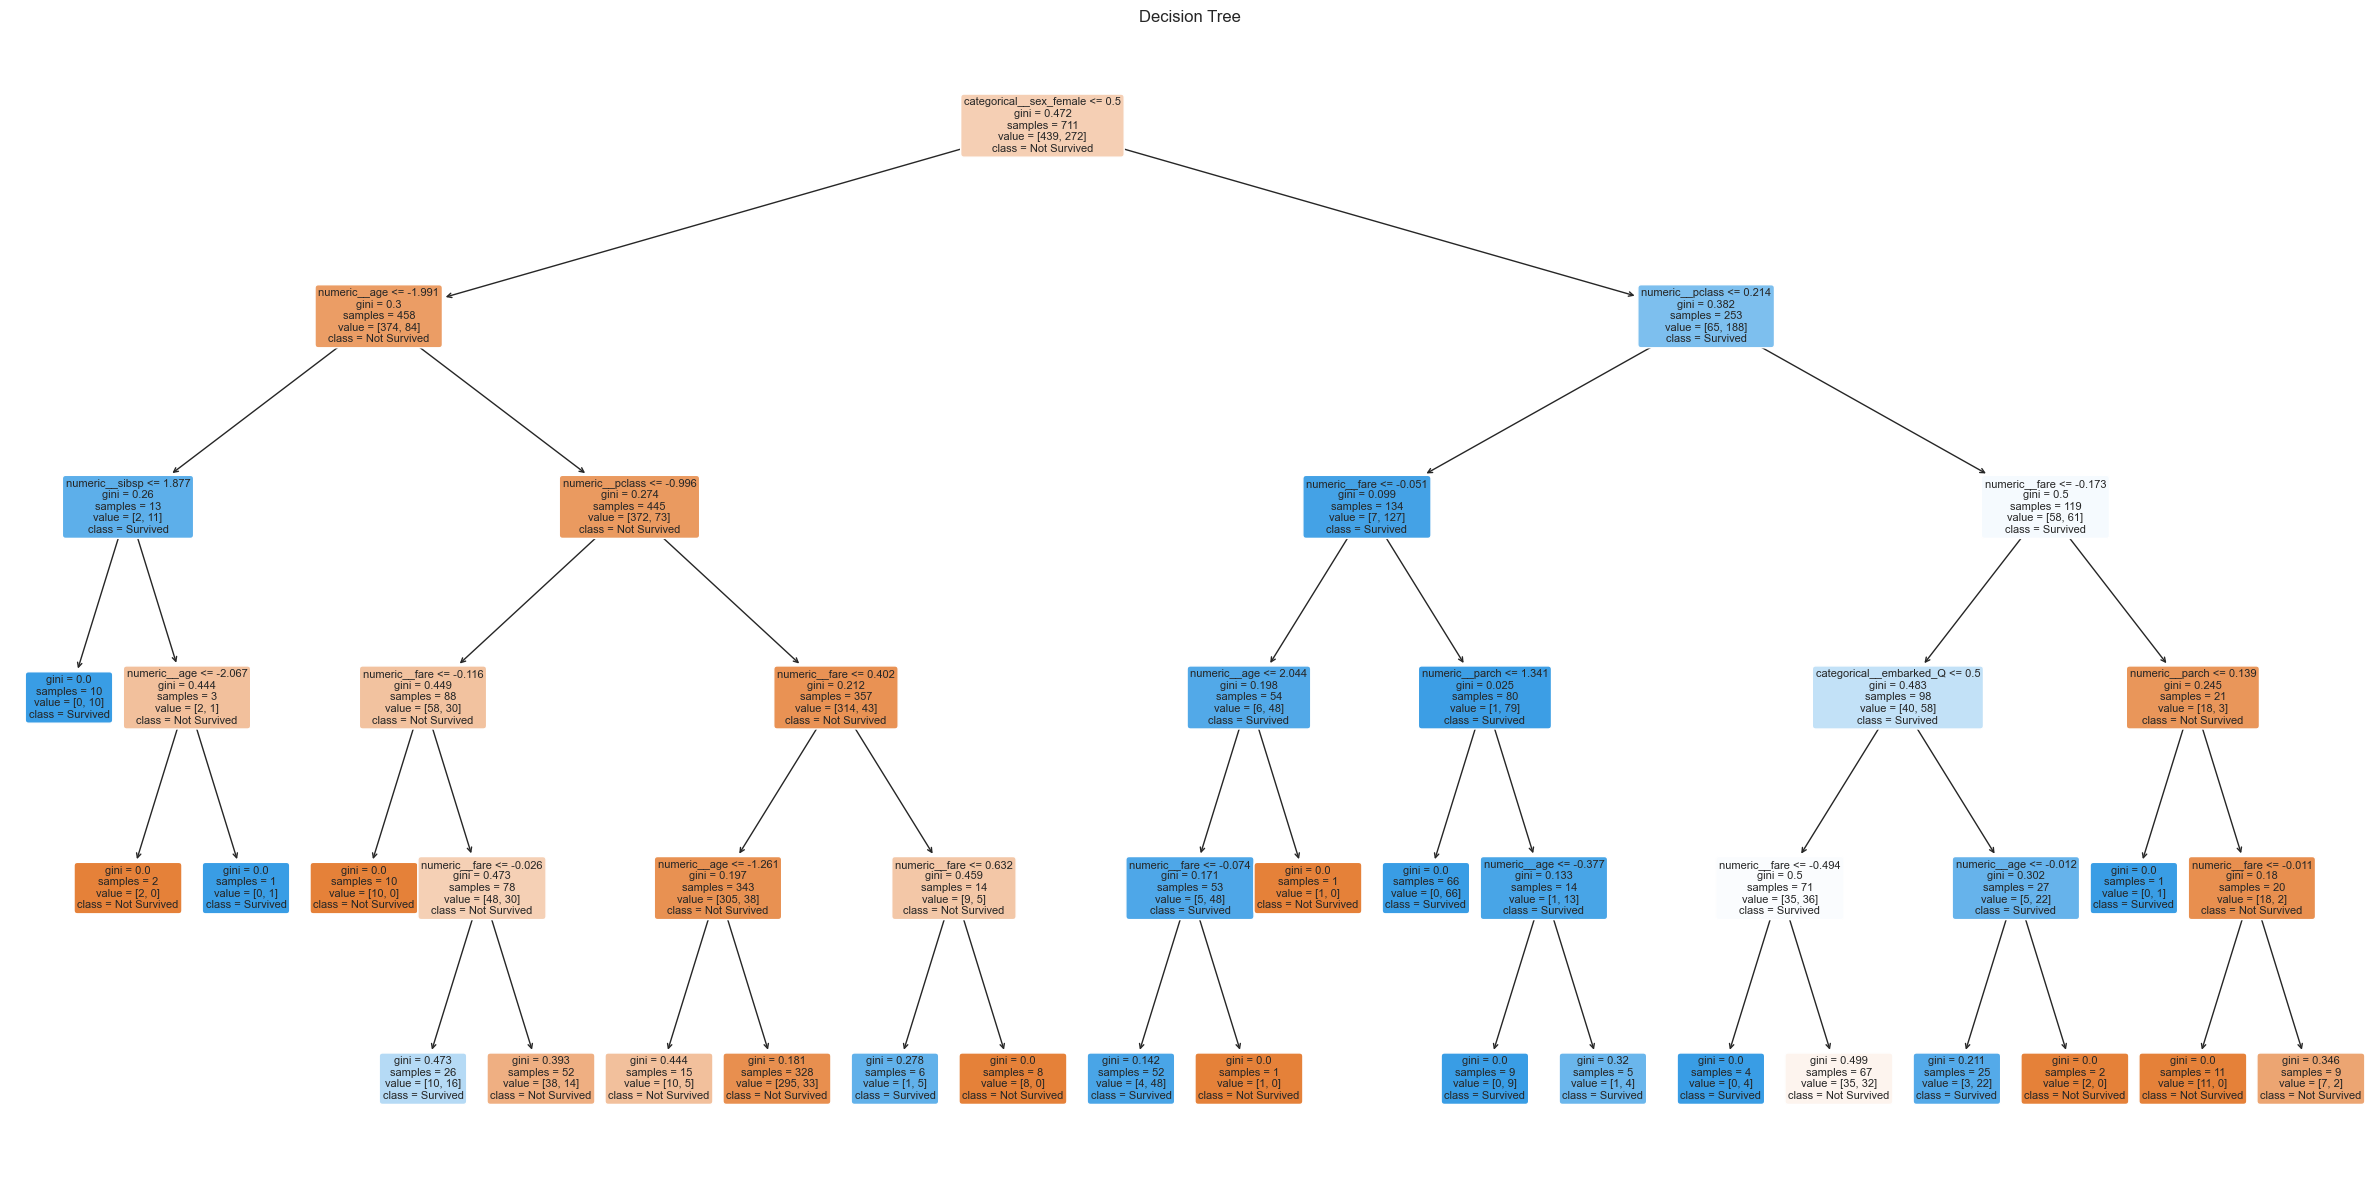

In [22]:
tree_model = decision_tree_pipeline.named_steps["model"]

tree_preprocessor = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
)

feature_names = (
    tree_preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "decision_tree.png"
    ),
    dpi=150
)

plt.show()

In [23]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_pipeline.fit(
    X_train,
    y_train
)

baseline_pred = baseline_pipeline.predict(X_test)

In [24]:
balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

balanced_pipeline.fit(
    X_train,
    y_train
)

balanced_pred = balanced_pipeline.predict(X_test)

In [25]:
smote_pipeline = ImbPipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(
                random_state=RANDOM_STATE
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

smote_pipeline.fit(
    X_train,
    y_train
)

smote_pred = smote_pipeline.predict(
    X_test
)

In [26]:
imbalance_results = []

variants = {
    "Baseline": baseline_pred,
    "Class Weight Balanced": balanced_pred,
    "SMOTE": smote_pred
}

for name, pred in variants.items():

    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

imbalance_table = pd.DataFrame(
    imbalance_results
)

imbalance_table.round(4)

,Strategy,Precision,Recall,F1
0,Baseline,0.7833,0.6912,0.7344
1,Class Weight Balanced,0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353


### Imbalance Strategy Conclusion

The three imbalance strategies produced very similar F1 scores. The
baseline achieved an F1 score of 0.7344, class-weight balancing achieved
0.7338, and SMOTE achieved the highest F1 score of 0.7353. SMOTE therefore
provided the strongest overall F1 result in this experiment, while
class-weight balancing achieved the highest recall of 0.7500. The
differences are small, so the choice depends on whether overall F1 or
higher recall is more important for the application.

In [27]:
print(
    "Compare the three strategies using precision, recall and F1. "
    "The preferred strategy for this task should be justified using "
    "the observed metric values and the relative importance of false "
    "positives versus false negatives."
)

Compare the three strategies using precision, recall and F1. The preferred strategy for this task should be justified using the observed metric values and the relative importance of false positives versus false negatives.


Compare the three strategies using precision, recall and F1. The preferred strategy for this task should be justified using the observed metric values and the relative importance of false positives versus false negatives.

In [28]:
rf_for_grid = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                oob_score=True,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [29]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

In [30]:
grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best CV F1:
0.7434141655760576


In [31]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = (
    best_rf_pipeline
    .named_steps["model"]
)

print(
    "OOB Score:",
    round(best_rf_model.oob_score_, 4)
)

OOB Score: 0.8073


In [32]:
regression_target = "fare"

regression_features = [
    column
    for column in df.columns
    if column != regression_target
]

X_reg = df[regression_features].copy()
y_reg = df[regression_target].copy()

print("Regression features:")
print(regression_features)

print("\nTarget:", regression_target)

Regression features:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Target: fare


In [33]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(X_reg_train.shape)
print(X_reg_test.shape)

(711, 13)
(178, 13)


In [34]:
reg_numeric_features = (
    X_reg_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

reg_categorical_features = (
    X_reg_train
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("Numeric:")
print(reg_numeric_features)

print("\nCategorical:")
print(reg_categorical_features)

Numeric:
['survived', 'pclass', 'age', 'sibsp', 'parch']

Categorical:
['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [35]:
reg_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

reg_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ]
)

In [36]:
regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['survived', 'pclass', 'age',
                                                   'sibsp', 'parch']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'adult_male',
                                                   'embark_town', 'alive',
                                                   'alone'])])),
                ('model', LinearRegression())])

In [37]:
y_reg_pred = regression_pipeline.predict(
    X_reg_test
)

In [38]:
mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 17.8151
RMSE : 41.3208
R²   : 0.3600


In [39]:
n = len(y_reg_test)

p = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
    .shape[1]
)

adjusted_r2 = (
    1
    - ((1 - r2) * (n - 1))
    / (n - p - 1)
)

print(f"Adjusted R²: {adjusted_r2:.4f}")

Adjusted R²: 0.2548


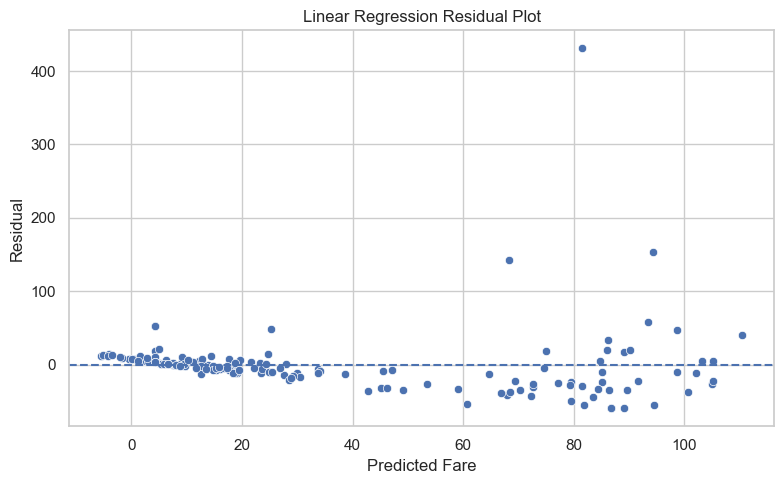

In [40]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Linear Regression Residual Plot")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "regression_residuals.png"
    ),
    dpi=150
)

plt.show()

### Heteroscedasticity Conclusion

The residual plot shows that the spread of residuals increases as predicted
fare increases. At lower predicted fare values, the residuals are relatively
concentrated around zero, while at higher predicted fare values, the residuals
show substantially greater variability with several large deviations.

This indicates visual evidence of heteroscedasticity in the linear regression
model.

In [41]:
final_classification_table = (
    classification_table[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AUC"
        ]
    ]
    .copy()
)

final_classification_table.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.809,0.7656,0.7206,0.7424,0.8211


In [42]:
regression_table = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted_R2": [adjusted_r2]
})

regression_table.round(4)

,Regression Model,MAE,RMSE,R2,Adjusted_R2
0,Linear Regression,17.8151,41.3208,0.36,0.2548


In [43]:
final_classification_table.sort_values(
    "F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,AUC
2,Random Forest,0.808989,0.765625,0.720588,0.742424,0.821056
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.764045,0.760000,0.558824,0.644068,0.837366


## Final Model Recommendation

Based on the evaluation results, the selected classifier is **Logistic Regression**.

Its accuracy was **0.808989**, precision was **0.783333**, recall was
**0.691176**, F1 was **0.734375**, and AUC was **0.860963**.

The model was selected because it achieved the highest AUC among the evaluated
classifiers while maintaining the same accuracy as Random Forest and the
highest precision of the three models. These metrics provide an appropriate
balance for the stated classification objective.

The regression model is evaluated separately using MAE, RMSE, R² and
Adjusted R²; these values are not directly comparable with the classification
metrics.

In [44]:
best_rf_model

RandomForestClassifier(n_estimators=200, n_jobs=-1, oob_score=True,
                       random_state=42)

In [45]:
full_pipeline = logistic_pipeline

In [46]:
model_path = os.path.join(
    MODEL_DIR,
    "best_pipeline.joblib"
)

joblib.dump(
    full_pipeline,
    model_path
)

print(
    f"Complete pipeline saved to: {model_path}"
)

Complete pipeline saved to: models/best_pipeline.joblib


In [52]:
loaded_pipeline = joblib.load(model_path)
print("Pipeline successfully reloaded.")
print(loaded_pipeline)
print("\nFinal estimator:")
print(loaded_pipeline.named_steps["model"])


Pipeline successfully reloaded.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                    

In [55]:
feature_columns = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
raw_sample = X_test[feature_columns].iloc[[0]]

print("Raw sample:")
display(raw_sample)

prediction = loaded_pipeline.predict(raw_sample)

probability = loaded_pipeline.predict_proba(raw_sample)

print("Prediction:", prediction)
print("Probability:", probability)

Raw sample:


,pclass,sex,age,sibsp,parch,fare,embarked
159,3,male,44.0,0,1,16.1,S


Prediction: [0]
Probability: [[0.94657804 0.05342196]]
